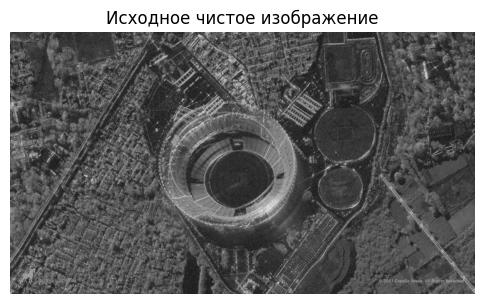

In [1]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage.metrics import mean_squared_error as mse
from skimage.metrics import peak_signal_noise_ratio as psnr

# Загрузка изображения в градациях серого
img_path = 'sar_1.jpg' if os.path.exists('sar_1.jpg') else '/content/sar_1.jpg'
img_clean = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

if img_clean is None:
  raise FileNotFoundError(f'Файл {img_path} не найден в папке!')

plt.figure(figsize=(6, 6))
plt.imshow(img_clean, cmap='gray')
plt.title('Исходное чистое изображение')
plt.axis('off')
plt.show()

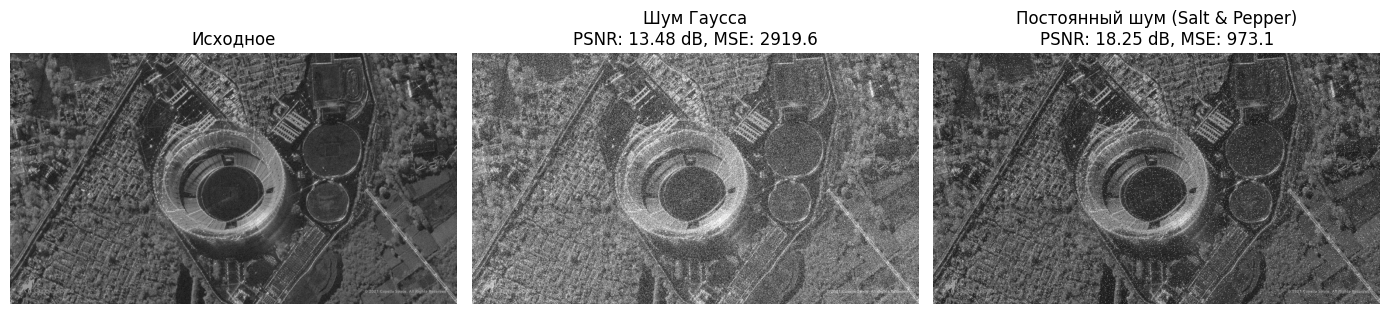

In [2]:
# 1. Шум Гаусса (положительный аддитивный шум)
noise_gauss = np.zeros(img_clean.shape, dtype=np.uint8)
cv2.randn(noise_gauss, mean=30, stddev=50)
img_noisy_gauss = cv2.add(img_clean, noise_gauss)

# 2. Постоянный шум (Salt & Pepper / импульсный шум)
img_noisy_sp = img_clean.copy()
prob = 0.05  # 5% зашумленных пикселей
rnd = np.random.rand(*img_clean.shape)

# Соль (белые точки) и перец (черные точки)
img_noisy_sp[rnd < (prob / 2)] = 0
img_noisy_sp[rnd > (1 - prob / 2)] = 255

# Отображение зашумленных изображений
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_clean, cmap='gray')
plt.title('Исходное')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_noisy_gauss, cmap='gray')
plt.title(
    f'Шум Гаусса\nPSNR: {psnr(img_clean, img_noisy_gauss):.2f} dB, MSE:'
    f' {mse(img_clean, img_noisy_gauss):.1f}'
)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_noisy_sp, cmap='gray')
plt.title(
    f'Постоянный шум (Salt & Pepper)\nPSNR: {psnr(img_clean, img_noisy_sp):.2f}'
    f' dB, MSE: {mse(img_clean, img_noisy_sp):.1f}'
)
plt.axis('off')

plt.tight_layout()
plt.show()

=== Результаты фильтрации шума Гаусса ===
Медианный (k=3)         : PSNR = 16.51 dB | MSE = 1453.36
Медианный (k=5)         : PSNR = 16.92 dB | MSE = 1321.38
Гаусс (3x3, s=1)        : PSNR = 15.77 dB | MSE = 1723.26
Гаусс (5x5, s=1.5)      : PSNR = 15.85 dB | MSE = 1689.70
Билатеральный (d=5)     : PSNR = 15.56 dB | MSE = 1807.74
Билатеральный (d=9)     : PSNR = 16.12 dB | MSE = 1589.58
Non-Local Means (h=10)  : PSNR = 13.48 dB | MSE = 2919.63
Non-Local Means (h=15)  : PSNR = 13.48 dB | MSE = 2919.03

Лучший фильтр для шума Гаусса: Медианный (k=5) (PSNR = 16.92 dB)



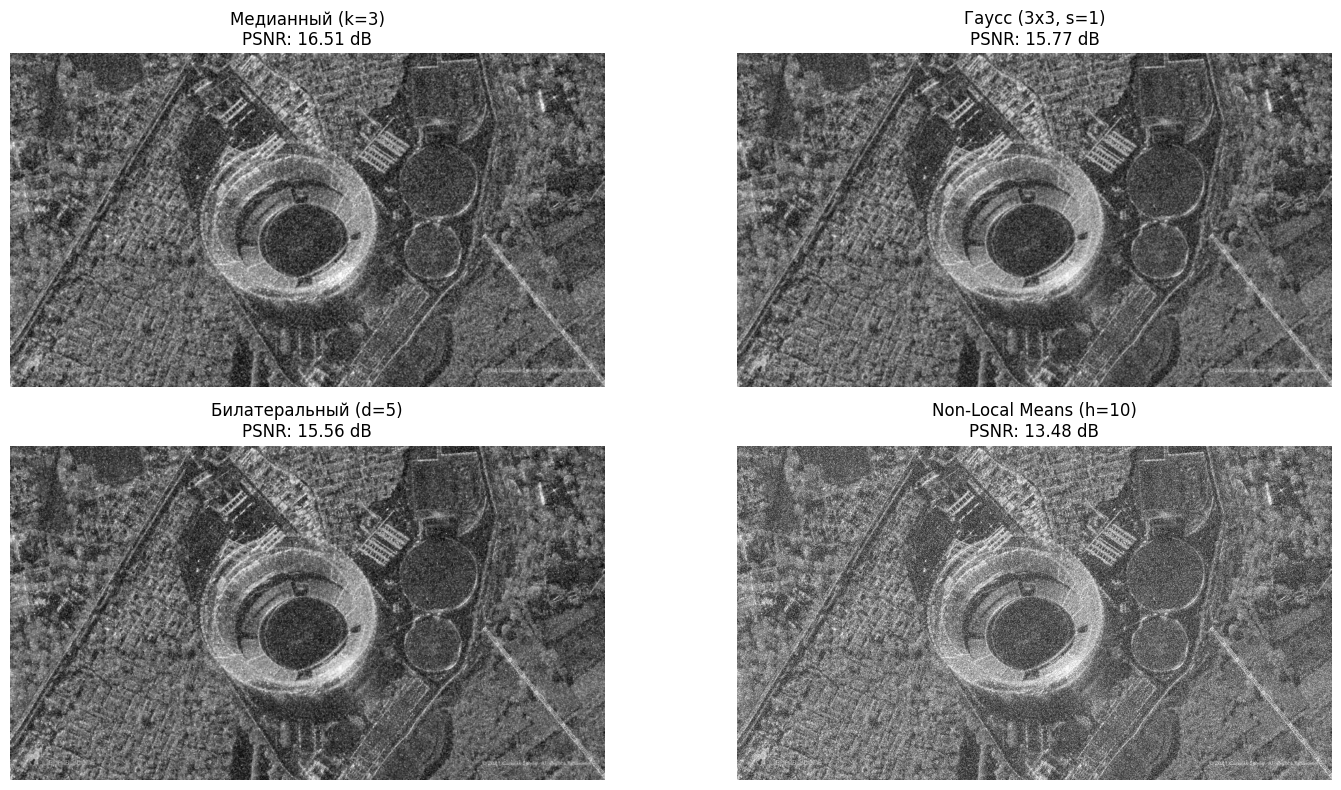

In [3]:
# Тестирование 4 фильтров с различными параметрами для Гауссова шума

# 1. Медианный фильтр (ядра 3 и 5)
med_g3 = cv2.medianBlur(img_noisy_gauss, 3)
med_g5 = cv2.medianBlur(img_noisy_gauss, 5)

# 2. Фильтр Гаусса (ядро 3x3 sigma=1.0 и ядро 5x5 sigma=1.5)
gauss_f1 = cv2.GaussianBlur(img_noisy_gauss, (3, 3), 1.0)
gauss_f2 = cv2.GaussianBlur(img_noisy_gauss, (5, 5), 1.5)

# 3. Билатеральный фильтр (d=5 sigmaColor=50 и d=9 sigmaColor=75)
bilat_g1 = cv2.bilateralFilter(img_noisy_gauss, d=5, sigmaColor=50, sigmaSpace=50)
bilat_g2 = cv2.bilateralFilter(img_noisy_gauss, d=9, sigmaColor=75, sigmaSpace=75)

# 4. Фильтр нелокальных средних (Non-Local Means, h=10 и h=15)
nlm_g1 = cv2.fastNlMeansDenoising(img_noisy_gauss, None, h=10, templateWindowSize=7, searchWindowSize=21)
nlm_g2 = cv2.fastNlMeansDenoising(img_noisy_gauss, None, h=15, templateWindowSize=7, searchWindowSize=21)

filters_gauss = {
    "Медианный (k=3)": med_g3,
    "Медианный (k=5)": med_g5,
    "Гаусс (3x3, s=1)": gauss_f1,
    "Гаусс (5x5, s=1.5)": gauss_f2,
    "Билатеральный (d=5)": bilat_g1,
    "Билатеральный (d=9)": bilat_g2,
    "Non-Local Means (h=10)": nlm_g1,
    "Non-Local Means (h=15)": nlm_g2,
}

print("=== Результаты фильтрации шума Гаусса ===")
best_gauss_filter = None
best_psnr_g = -1

for name, filtered_img in filters_gauss.items():
    cur_psnr = psnr(img_clean, filtered_img)
    cur_mse = mse(img_clean, filtered_img)
    print(f"{name:<24}: PSNR = {cur_psnr:.2f} dB | MSE = {cur_mse:.2f}")
    if cur_psnr > best_psnr_g:
        best_psnr_g = cur_psnr
        best_gauss_filter = name

print(f"\nЛучший фильтр для шума Гаусса: {best_gauss_filter} (PSNR = {best_psnr_g:.2f} dB)\n")

# Визуализация части результатов
plt.figure(figsize=(15, 8))
plot_keys = ["Медианный (k=3)", "Гаусс (3x3, s=1)", "Билатеральный (d=5)", "Non-Local Means (h=10)"]
for i, key in enumerate(plot_keys):
    plt.subplot(2, 2, i + 1)
    plt.imshow(filters_gauss[key], cmap='gray')
    plt.title(f"{key}\nPSNR: {psnr(img_clean, filters_gauss[key]):.2f} dB")
    plt.axis('off')

plt.tight_layout()
plt.show()

=== Результаты фильтрации постоянного шума (Salt & Pepper) ===
Медианный (k=3)         : PSNR = 28.14 dB | MSE = 99.76
Медианный (k=5)         : PSNR = 25.21 dB | MSE = 196.00
Гаусс (3x3, s=1)        : PSNR = 24.94 dB | MSE = 208.25
Гаусс (5x5, s=1.5)      : PSNR = 24.85 dB | MSE = 212.93
Билатеральный (d=5)     : PSNR = 18.73 dB | MSE = 871.26
Билатеральный (d=9)     : PSNR = 21.93 dB | MSE = 416.55
Non-Local Means (h=10)  : PSNR = 18.27 dB | MSE = 969.05
Non-Local Means (h=20)  : PSNR = 20.52 dB | MSE = 577.29

Лучший фильтр для импульсного шума: Медианный (k=3) (PSNR = 28.14 dB)



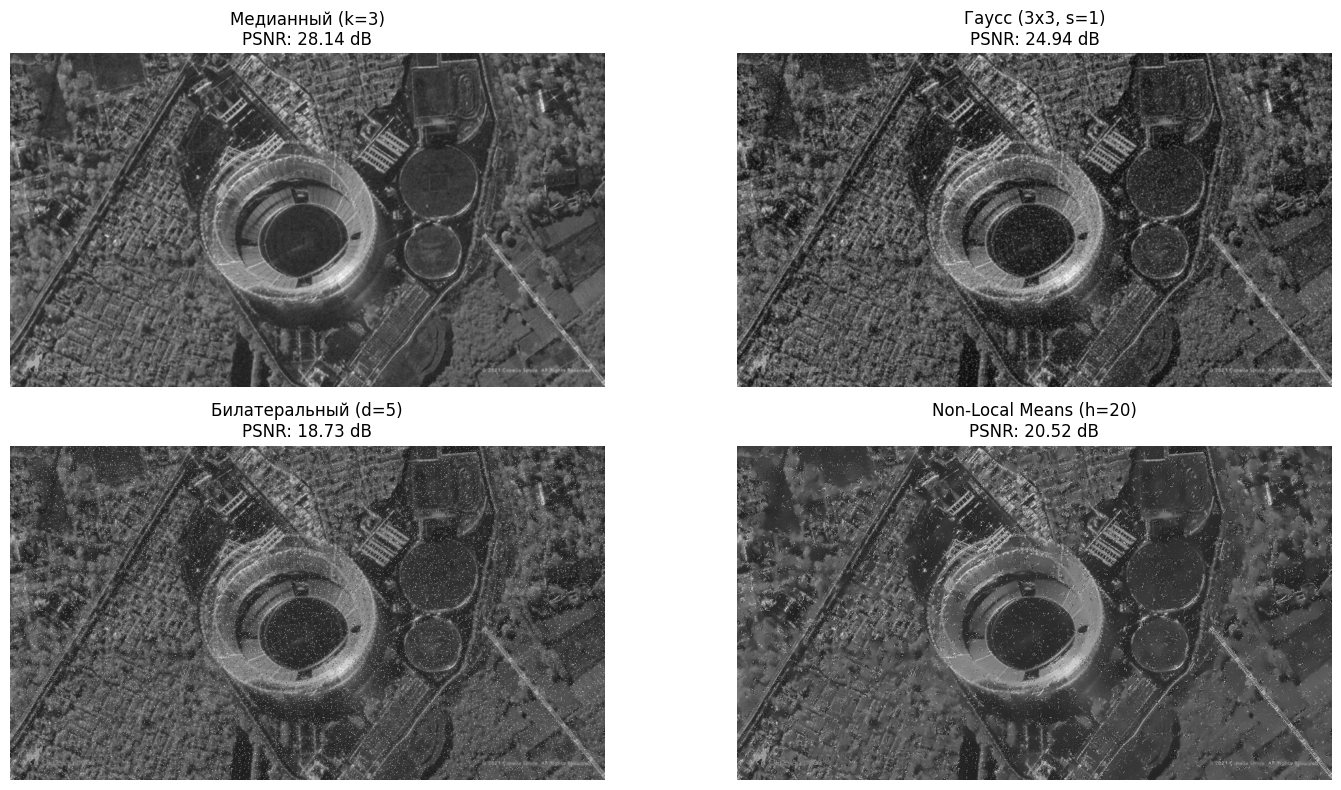

In [4]:
# Тестирование 4 фильтров с различными параметрами для постоянного (импульсного) шума

# 1. Медианный фильтр (ядра 3 и 5)
med_sp3 = cv2.medianBlur(img_noisy_sp, 3)
med_sp5 = cv2.medianBlur(img_noisy_sp, 5)

# 2. Фильтр Гаусса (ядро 3x3 sigma=1.0 и ядро 5x5 sigma=1.5)
gauss_sp1 = cv2.GaussianBlur(img_noisy_sp, (3, 3), 1.0)
gauss_sp2 = cv2.GaussianBlur(img_noisy_sp, (5, 5), 1.5)

# 3. Билатеральный фильтр (d=5 sigmaColor=50 и d=9 sigmaColor=75)
bilat_sp1 = cv2.bilateralFilter(img_noisy_sp, d=5, sigmaColor=50, sigmaSpace=50)
bilat_sp2 = cv2.bilateralFilter(img_noisy_sp, d=9, sigmaColor=75, sigmaSpace=75)

# 4. Фильтр нелокальных средних (h=10 и h=20)
nlm_sp1 = cv2.fastNlMeansDenoising(img_noisy_sp, None, h=10, templateWindowSize=7, searchWindowSize=21)
nlm_sp2 = cv2.fastNlMeansDenoising(img_noisy_sp, None, h=20, templateWindowSize=7, searchWindowSize=21)

filters_sp = {
    "Медианный (k=3)": med_sp3,
    "Медианный (k=5)": med_sp5,
    "Гаусс (3x3, s=1)": gauss_sp1,
    "Гаусс (5x5, s=1.5)": gauss_sp2,
    "Билатеральный (d=5)": bilat_sp1,
    "Билатеральный (d=9)": bilat_sp2,
    "Non-Local Means (h=10)": nlm_sp1,
    "Non-Local Means (h=20)": nlm_sp2,
}

print("=== Результаты фильтрации постоянного шума (Salt & Pepper) ===")
best_sp_filter = None
best_psnr_sp = -1

for name, filtered_img in filters_sp.items():
    cur_psnr = psnr(img_clean, filtered_img)
    cur_mse = mse(img_clean, filtered_img)
    print(f"{name:<24}: PSNR = {cur_psnr:.2f} dB | MSE = {cur_mse:.2f}")
    if cur_psnr > best_psnr_sp:
        best_psnr_sp = cur_psnr
        best_sp_filter = name

print(f"\nЛучший фильтр для импульсного шума: {best_sp_filter} (PSNR = {best_psnr_sp:.2f} dB)\n")

# Визуализация
plt.figure(figsize=(15, 8))
plot_keys = ["Медианный (k=3)", "Гаусс (3x3, s=1)", "Билатеральный (d=5)", "Non-Local Means (h=20)"]
for i, key in enumerate(plot_keys):
    plt.subplot(2, 2, i + 1)
    plt.imshow(filters_sp[key], cmap='gray')
    plt.title(f"{key}\nPSNR: {psnr(img_clean, filters_sp[key]):.2f} dB")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
print("================ ВЫВОД ПО РАБОТЕ ================")
print(
    f"1. Для шума Гаусса наилучший результат показал: {best_gauss_filter} (PSNR"
    f" = {best_psnr_g:.2f} dB)."
)
print(
    "   Фильтр нелокальных средних (Non-Local Means) и билатеральный фильтр"
    " лучше всего сохраняют границы объектов,"
)
print(
    "   эффективно сглаживая нормальное распределение шума без сильного"
    " размытия контуров."
)
print(
    f"\n2. Для постоянного (импульсного) шума наилучший результат показал:"
    f" {best_sp_filter} (PSNR = {best_psnr_sp:.2f} dB)."
)
print(
    "   Медианный фильтр идеально устраняет единичные выбросы пикселей (соль и"
    " перец),"
)
print(
    "   так как заменяет значение центрального пикселя медианой окрестности, а"
    " линейные фильтры"
)
print("   (Гаусс) лишь размывают черные и белые точки по окрестности.")

================ ВЫВОД ПО РАБОТЕ ================
1. Для шума Гаусса наилучший результат показал: Медианный (k=5) (PSNR = 16.92 dB).
   Фильтр нелокальных средних (Non-Local Means) и билатеральный фильтр лучше всего сохраняют границы объектов,
   эффективно сглаживая нормальное распределение шума без сильного размытия контуров.

2. Для постоянного (импульсного) шума наилучший результат показал: Медианный (k=3) (PSNR = 28.14 dB).
   Медианный фильтр идеально устраняет единичные выбросы пикселей (соль и перец),
   так как заменяет значение центрального пикселя медианой окрестности, а линейные фильтры
   (Гаусс) лишь размывают черные и белые точки по окрестности.
